# Week 2 — Hidden state estimation (NumPy)

Every figure and every number on the Week 2 pages, rebuilt from scratch.
Nothing is hidden inside a library call.

The running problem: an animal hears a sound and infers how far away the
source is. Intensity falls as the inverse square of distance, so the link
between what it wants and what it measures is nonlinear, and that is the
whole point.

**Contents**

1. The model, and why it is not as easy as it looks
2. The exact posterior by quadrature
3. Gradient ascent on the log joint
4. The two prediction errors
5. How large a step the ascent tolerates
6. The linear case, where a closed form exists
7. Two ways the method fails

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1. The model

Three ingredients: a link function `g`, a Gaussian likelihood around it, and
a Gaussian prior over the hidden distance.

Note that `g` and `g_prime` are the only place the physics enters. Everything
below is written in terms of them, so swapping in a different world (the
exponential absorption of the first problem, say) means changing two lines.

In [2]:
d_p, var_p = 2.0, 1.0      # the animal expects sources about 2 units away
u,   var_u = 0.50, 0.10    # the intensity it actually heard, and its noise

g       = lambda d: 1.0 / d**2
g_prime = lambda d: -2.0 / d**3

print(f'prior mean {d_p} predicts intensity {g(d_p):.4f}')
print(f'heard                              {u:.4f}')
print(f'data alone would say d = {np.sqrt(1.0 / u):.4f}')

prior mean 2.0 predicts intensity 0.2500
heard                              0.5000
data alone would say d = 1.4142


The prior says one thing and the data another. The answer is somewhere
between, and finding where is the week's work.

## 2. The exact posterior by quadrature

One hidden variable, so we can afford brute force: evaluate the unnormalised
posterior on a fine grid and normalise numerically. This is the answer
everything else gets checked against.

It is also the method that does not scale. With ten hidden variables the same
grid would need 10**60 points.

In [3]:
grid = np.linspace(0.05, 8.0, 600_000)

log_post = (-(grid - d_p)**2 / (2*var_p)
            - (u - g(grid))**2 / (2*var_u))
post = np.exp(log_post - log_post.max())
post /= np.trapezoid(post, grid)

mode = grid[post.argmax()]
mean = np.trapezoid(grid * post, grid)
sd   = np.sqrt(np.trapezoid((grid - mean)**2 * post, grid))
skew = np.trapezoid(((grid - mean) / sd)**3 * post, grid)

print(f'mode {mode:.4f}   mean {mean:.4f}   gap {100*(mean-mode)/mode:.1f}%')
print(f'sd   {sd:.4f}   skew {skew:+.4f}')

mode 1.5500   mean 2.0900   gap 34.8%
sd   0.7210   skew +0.8811


Both ingredients were Gaussian and the result is not. A Gaussian has zero
skew; this has a substantial one, and its mode and mean differ by about a
third. Section 6 shows that the link function is responsible and the prior
is not.

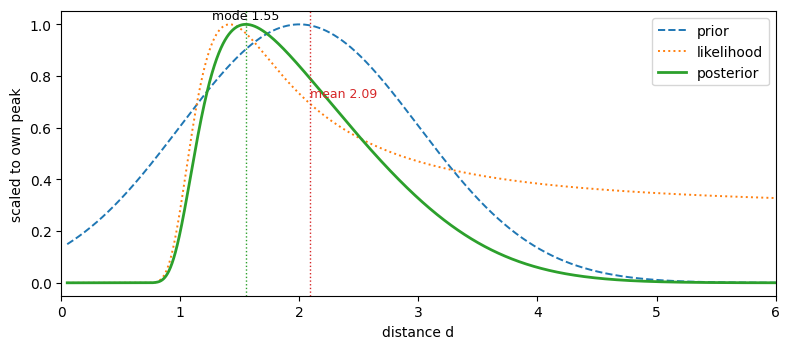

In [4]:
prior_c = np.exp(-(grid - d_p)**2 / (2*var_p))
lik_c   = np.exp(-(u - g(grid))**2 / (2*var_u))

fig, ax = plt.subplots(figsize=(8, 3.6))
for c, lab, sty in ((prior_c, 'prior', '--'), (lik_c, 'likelihood', ':'),
                    (post, 'posterior', '-')):
    ax.plot(grid, c / c.max(), sty, label=lab, lw=2 if sty == '-' else 1.4)
ax.axvline(mode, color='C2', lw=1, ls=':')
ax.axvline(mean, color='C3', lw=1, ls=':')
ax.annotate(f'mode {mode:.2f}', (mode, 1.02), ha='center', fontsize=9)
ax.annotate(f'mean {mean:.2f}', (mean, 0.72), fontsize=9, color='C3')
ax.set_xlim(0, 6); ax.set_xlabel('distance d')
ax.set_ylabel('scaled to own peak'); ax.legend(); plt.tight_layout()

## 3. Gradient ascent on the log joint

The normaliser does not depend on `d`, so it has no bearing on *where* the
posterior peaks and cancels exactly. That leaves the log joint

    F(d) = ln P(d) + ln P(u | d)

whose gradient is two precision-weighted prediction errors. Climb it.

In [5]:
def gradient(d):
    """The two terms of dF/dd, returned separately so they can be watched."""
    eps_p = (d_p - d) / var_p                 # prior prediction error
    eps_u = (u - g(d)) / var_u                # sensory prediction error
    return eps_p, g_prime(d) * eps_u


def ascend(d0=d_p, eta=0.05, steps=400):
    d, path, terms = d0, [d0], []
    for _ in range(steps):
        a, b = gradient(d)
        terms.append((a, b))
        d += eta * (a + b)
        path.append(d)
    return np.array(path), np.array(terms)


path, terms = ascend()
print(f'ascent settles at {path[-1]:.6f}')
print(f'quadrature mode   {mode:.6f}')

ascent settles at 1.550036
quadrature mode   1.550035


Two methods that share no code agree to four decimal places, the residual
being the grid spacing. That is the check worth making: if you had reused
one function for both, agreement would prove nothing, because the ways each
could be wrong would be the same ways.

## 4. The two prediction errors

The estimate settles where the two terms cancel, not where either is zero.
The animal has *not* explained the observation away; it has stopped where
explaining more would cost more in prior implausibility than it gains in fit.

prior term    +0.449964
sensory term  -0.449964
sum           -1.55e-15

raw sensory error is still 0.8379, and g(d) = 0.4162 against u = 0.5


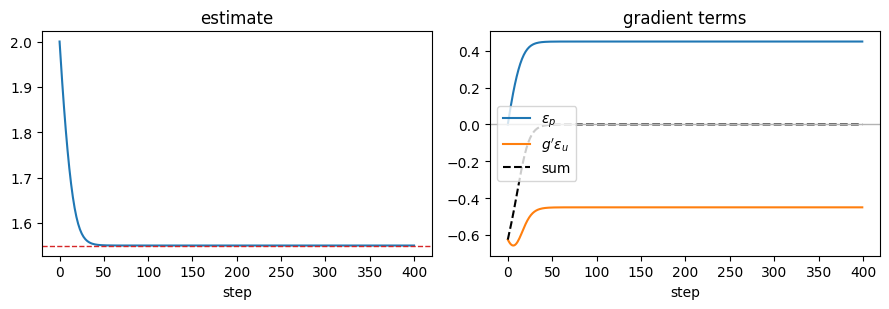

In [6]:
a, b = terms[-1]
print(f'prior term    {a:+.6f}')
print(f'sensory term  {b:+.6f}')
print(f'sum           {a+b:.2e}')
print()
print(f'raw sensory error is still {(u - g(path[-1]))/var_u:.4f},',
      f'and g(d) = {g(path[-1]):.4f} against u = {u}')

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(path); ax[0].axhline(mode, color='C3', ls='--', lw=1)
ax[0].set_title('estimate'); ax[0].set_xlabel('step')
ax[1].plot(terms[:, 0], label=r'$\varepsilon_p$')
ax[1].plot(terms[:, 1], label=r"$g'\varepsilon_u$")
ax[1].plot(terms.sum(1), 'k--', label='sum')
ax[1].axhline(0, color='0.7', lw=1)
ax[1].set_title('gradient terms'); ax[1].set_xlabel('step'); ax[1].legend()
plt.tight_layout()

## 5. How large a step the ascent tolerates

Linearising the update about the peak gives

    e[k+1] = (1 + eta * F''(d*)) * e[k]

so the iteration converges only while `|1 + eta F''| < 1`, that is
`eta < 2 / |F''|`. Since a sharper sensor makes a sharper peak, trusting your
senses more makes the inference stiffer. Watch a rate that worked at
`var_u = 0.1` fail at `var_u = 0.01`.

In [7]:
def curvature(d, vu=var_u, h=1e-5):
    F = lambda x: -(x - d_p)**2/(2*var_p) - (u - g(x))**2/(2*vu)
    return (F(d + h) - 2*F(d) + F(d - h)) / h**2


def ascend_vu(vu, d0=d_p, eta=0.05, steps=400):
    d = d0
    for _ in range(steps):
        d += eta * ((d_p - d)/var_p + (u - g(d))/vu * g_prime(d))
        d = min(max(d, 0.05), 8.0)
    return d


for vu in (1.0, 0.1, 0.01):
    lp = -(grid - d_p)**2/(2*var_p) - (u - g(grid))**2/(2*vu)
    pk = grid[lp.argmax()]
    c  = curvature(pk, vu)
    print(f'var_u {vu:<6} peak {pk:.4f}  F\'\' {c:>9.2f}  '
          f'eta_max {2/abs(c):.4f}  ascent at eta=0.05 -> {ascend_vu(vu):.4f}')

var_u 1.0    peak 1.9357  F''     -0.98  eta_max 2.0483  ascent at eta=0.05 -> 1.9357
var_u 0.1    peak 1.5500  F''     -3.01  eta_max 0.6637  ascent at eta=0.05 -> 1.5500
var_u 0.01   peak 1.4261  F''    -47.34  eta_max 0.0423  ascent at eta=0.05 -> 1.3493


At `var_u = 0.01` the bound falls below the rate in use and the estimate
never settles. Print the last few iterates and you find a clean two-cycle
straddling the peak it can no longer land on.

In [8]:
d, tail = d_p, []
for k in range(200):
    d += 0.05 * ((d_p - d)/var_p + (u - g(d))/0.01 * g_prime(d))
    d = min(max(d, 0.05), 8.0)
    if k > 192: tail.append(round(d, 4))
print('last iterates:', tail)

last iterates: [1.3493, 1.5824, 1.3493, 1.5824, 1.3493, 1.5824, 1.3493]


## 6. The linear case

Replace the inverse square with the identity and everything becomes exact.
The estimate is the precision-weighted average of prior mean and measurement,
the precisions simply add, and the posterior is Gaussian.

The grid has to be widened for this check. On `d > 0.05` the linear posterior
sits close enough to the origin that the cut removes part of its left tail,
and the check would be measuring the truncation instead of the algebra.

In [9]:
wide = np.linspace(-6.0, 8.0, 600_000)
lin  = np.exp(-(wide - d_p)**2/(2*var_p) - (u - wide)**2/(2*var_u))
lin /= np.trapezoid(lin, wide)

P_p, P_u = 1/var_p, 1/var_u
closed_form = (P_p*d_p + P_u*u) / (P_p + P_u)

lin_mean = np.trapezoid(wide * lin, wide)
lin_sd   = np.sqrt(np.trapezoid((wide - lin_mean)**2 * lin, wide))
lin_skew = np.trapezoid(((wide - lin_mean)/lin_sd)**3 * lin, wide)

print(f'closed form  {closed_form:.6f}   variance {1/(P_p+P_u):.6f}')
print(f'quadrature   mode {wide[lin.argmax()]:.6f}  mean {lin_mean:.6f}')
print(f'skew         {lin_skew:.2e}   (zero to machine precision)')

below = wide < 0
print(f'\nmass at negative distance: {np.trapezoid(lin[below], wide[below]):.4f}')
near = grid < 0.5
print(f'nonlinear posterior below d=0.5: {np.trapezoid(post[near], grid[near]):.1e}')

closed form  0.636364   variance 0.090909
quadrature   mode 0.636361  mean 0.636364
skew         -8.84e-16   (zero to machine precision)

mass at negative distance: 0.0174
nonlinear posterior below d=0.5: 1.0e-30


Mode and mean agree to five figures and part of the sixth, and the skew is
machine zero, so the
entire gap of section 2 is the nonlinearity and none of it is the prior.

The last two numbers are the bill for using a Gaussian prior over a distance.
In the linear case a real slice of the posterior sits at negative distances.
In the nonlinear case it does not, because `g(d)` runs to infinity as `d`
approaches zero and the likelihood suppresses the region for us.

## 7. Two ways the method fails

Both are properties of the method rather than of this example, and neither
announces itself. The gradient reaches zero and the errors balance in both.

**Local maxima.** Move the prior out and sharpen the ear, and the log joint
grows a second peak.

In [10]:
bi = dict(d_p=4.0, var_p=0.5, u=1.5, var_u=0.1)
bg = np.linspace(0.05, 10.0, 400_000)
bq = np.exp(-(bg - bi['d_p'])**2/(2*bi['var_p'])
            - (bi['u'] - g(bg))**2/(2*bi['var_u']))
bq /= bq.max()
pk = np.where((bq[1:-1] > bq[:-2]) & (bq[1:-1] > bq[2:]))[0] + 1
pk = [i for i in pk if bq[i] > 1e-6]
print('peaks at', [(round(float(bg[i]), 4), round(float(bq[i]), 4)) for i in pk])


def bi_ascend(d0, eta=0.02, steps=6000):
    d = d0
    for _ in range(steps):
        d += eta * ((bi['d_p'] - d)/bi['var_p']
                    + (bi['u'] - g(d))/bi['var_u'] * g_prime(d))
        d = min(max(d, 0.05), 10.0)
    return d


for start in (bi['d_p'], 2.0, 1.0, 0.6):
    print(f'  from {start:>4} -> {bi_ascend(start):.4f}')

peaks at [(0.8817, 1.0), (3.7234, 0.7272)]
  from  4.0 -> 3.7234
  from  2.0 -> 3.7234
  from  1.0 -> 0.8817
  from  0.6 -> 3.7234


From the prior mean it climbs the *lower* peak and stops, never learning that
a taller one exists. From `0.6` it does something else again: the gradient
there is enormous, so a rate that is mild elsewhere throws the estimate clear
across the range.

**The mode moves when you rename the axis.** Estimate `rho = ln d` instead of
`d`. It is the same physical situation in different coordinates, and the
change of variables multiplies the density by the Jacobian `|dd/drho| = d`.

In [11]:
logp_d   = -(grid - d_p)**2/(2*var_p) - (u - g(grid))**2/(2*var_u)
logp_rho = logp_d + np.log(grid)          # the Jacobian, in logs

map_d   = grid[logp_d.argmax()]
map_rho = grid[logp_rho.argmax()]
print(f'MAP in d          {map_d:.4f}')
print(f'MAP via ln d      {map_rho:.4f}   ({100*(map_rho-map_d)/map_d:+.1f}%)')
print(f'posterior mean    {mean:.4f}   (unchanged either way)')

MAP in d          1.5500
MAP via ln d      1.8787   (+21.2%)
posterior mean    2.0900   (unchanged either way)


A density is a quantity per unit of something, and the unit changed. So the
location of its peak is a property of the coordinates as much as of the
belief, and nothing physical distinguishes distance from log-distance.
Quantities defined by expectation do not have this problem, which is a reason
to prefer methods built on them. Week 4's free energy is one.

---

The problems on the Week 2 page go further: an exponentially absorbing world,
repeated and sequential listening, and what a logarithmic ear buys.